In [1]:
# standard python imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# tidy3d imports
import tidy3d as td
import tidy3d.web as web
web.configure(apikey="U6iK3TqIEeIQMdk7ELMzDioV6R4abyHl0M4kEcYh9NmizmJD")

from tidy3d import material_library

sim_path = "220_1550/with_mirror"

Configuration saved successfully.


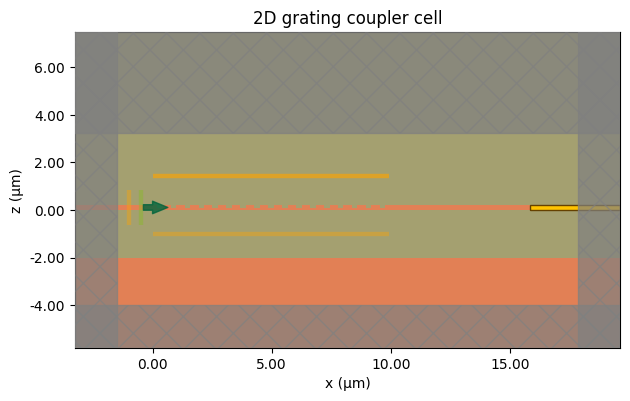

In [15]:
def create_2d_gc_simulation(wvl0=1.550, wg_thick=0.22, etch_depth=0.13, period=0.585, duty_cycle=0.400, mirror_shift=5.900):
    # paper-inspired 2D grating coupler on SOI
    bandwidth = 0.020 # in um
    wvls = np.linspace(wvl0 - bandwidth/2, wvl0 + bandwidth/2, 51)
    freq0 = td.C_0 / wvl0
    freqs = td.C_0 / wvls

    si = material_library['cSi']['Palik_Lossless']
    sio2 = material_library['SiO2']['Palik_Lossless']
    au = material_library['Au']['JohnsonChristy1972']
    air = td.Medium(permittivity=1.0)

    # SOI stack dimensions (micron)
    t_si = wg_thick
    t_box = 2.0
    t_sub = 2.0
    t_clad = 3.0

    # Diameter follows duty_cycle * period, radius is half the diameter.
    hole_diameter = duty_cycle * period
    hole_radius = 0.5 * hole_diameter

    # Match the fiber-core-scale grating length (~10 um).
    grating_length = 10.0
    num_periods = int(np.round(grating_length / period))
    grating_length = num_periods * period
    mirror_thickness_x = 2.0

    # Simulation padding
    buffer = 5.0

    # Input waveguide before grating and continuous slab up to mirror start
    input_wg_length = 1.5
    x_grating_start = 0.0
    x_grating_end = grating_length
    x_slab_start = -input_wg_length
    x_slab_end = x_grating_end + mirror_shift
    x_mirror_start = x_slab_end
    x_mirror_end = x_mirror_start + mirror_thickness_x

    # Vertical references
    z_si_bottom = 0.0
    z_si_top = z_si_bottom + t_si
    z_box_top = z_si_bottom
    z_box_bottom = z_box_top - t_box
    z_sub_top = z_box_bottom
    z_sub_bottom = z_sub_top - t_sub
    z_clad_top = z_si_top + t_clad
    z_clad_bottom = z_clad_top - t_clad

    # Simulation domain
    sim_width_y = period
    sim_x_min = x_slab_start
    sim_x_max = x_mirror_end
    sim_center_x = 0.5 * (sim_x_min + sim_x_max)
    sim_size_x = sim_x_max - sim_x_min
    sim_z_min = z_sub_bottom
    sim_z_max = z_clad_top
    sim_center_z = 0.5 * (sim_z_min + sim_z_max)
    sim_size_z = sim_z_max - sim_z_min

    # SOI layers
    sio2_clad = td.Structure(
        geometry=td.Box(
            center=(0, 0, 0),
            size=(td.inf, td.inf, td.inf),
        ),
        medium=sio2,
        name='sio2_clad',
    )
    si_substrate = td.Structure(
        geometry=td.Box(
            center=(0, 0, 0.5 * (z_sub_top + z_sub_bottom - buffer)),
            size=(td.inf, td.inf, t_sub + buffer),
        ),
        medium=si,
        name='si_substrate',
    )

    si_slab = td.Structure(
        geometry=td.Box(
            center=(0.5 * (x_slab_start + x_slab_end - buffer), 0, z_si_bottom + t_si / 2),
            size=(x_slab_end - x_slab_start + buffer, td.inf, t_si),
        ),
        medium=si,
        name='si_slab'
    )

    hole_geometries = []
    for i in range(num_periods):
        hole_geometries.append(
            td.Cylinder(
                center=(x_grating_start + (i + 0.5) * period, 0, z_si_top - etch_depth / 2),
                radius=hole_radius,
                length=etch_depth,
                axis=2,
            )
        )

    etch_holes = td.Structure(
        geometry=td.GeometryGroup(geometries=hole_geometries), 
        medium=sio2, 
        name='etch_holes'
    )

    # PEC mirror with explicit x-gap from grating end (mirror_shift).
    pec_mirror = td.Structure(
        geometry=td.Box(
            center=(0.5 * (x_mirror_start + x_mirror_end + buffer), 0, z_si_bottom + t_si / 2),
            size=(mirror_thickness_x + buffer, td.inf, t_si),
        ),
        medium=td.PECMedium(),
        name='pec_mirror'
    )

    source = td.ModeSource(
        center=(x_slab_start + 1.0, 0, z_si_bottom + t_si / 2),
        size=(0, td.inf, 1.5),
        direction='+',
        mode_spec=td.ModeSpec(num_modes=1, target_neff=2.8),
        source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0/20),
        name='input_source',
    )

    apod = td.ApodizationSpec(
        start=0,          # Window is fully open at the beginning
        end=4.5e-12,      # Start the fade-out at 4.5 ps
        width=0.5e-12     # Make the fade-out take exactly 0.5 ps
    )

    near_field_line = td.FieldMonitor(
        center=(0.5 * (x_grating_start + x_grating_end), 0, z_si_top + 1.2),
        size=(grating_length, 0, 0), # 1D line along X
        freqs=[freq0],
        name="near_field_line"
    )

    # Flux Monitors
    upward_monitor = td.FluxMonitor(
        center=(0.5 * (x_grating_start + x_grating_end), 0, z_si_top + 1.2),
        size=(grating_length, td.inf, 0),
        freqs=freqs,
        name='upward_flux',
        apodization=apod
    )
    downward_monitor = td.FluxMonitor(
        center=(0.5 * (x_grating_start + x_grating_end), 0, 0.5 * (z_box_top + z_box_bottom)),
        size=(grating_length, td.inf, 0),
        freqs=freqs,
        name='downward_flux',
        apodization=apod
    )
    backward_monitor = td.FluxMonitor(
        center=(x_slab_start + 0.5, 0, z_si_bottom + t_si / 2),
        size=(0, td.inf, 1.5),
        freqs=freqs,
        name='backward_flux',
        apodization=apod
    )

    # Field Monitors
    fieldxz_monitor = td.FieldMonitor(
        center=(0, 0, 0),
        size=(td.inf, 0, td.inf),
        freqs=[freq0],
        name='field_xz',
        apodization=apod
    )

    sim = td.Simulation(
        center=(sim_center_x, 0, sim_center_z),
        size=(sim_size_x, sim_width_y, sim_size_z),
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=10, wavelength=wvl0),
        structures=[sio2_clad, si_substrate, si_slab, etch_holes, pec_mirror],
        sources=[source],
        monitors=[upward_monitor, downward_monitor, backward_monitor, fieldxz_monitor, near_field_line],
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.absorber(),
            y=td.Boundary.periodic(),
            z=td.Boundary.absorber(),
        ),
        # medium=air,
        run_time=5e-12,
        shutoff=1e-5,
    )

    return sim

sim = create_2d_gc_simulation(mirror_shift=5.900, period=0.585, duty_cycle=0.400)
ax = sim.plot(y=0)
ax.set_title('2D grating coupler cell')
plt.show()

In [4]:
sim.plot_3d()

In [9]:
import numpy as np
import tidy3d as td

def extract_gc_performance(sim_data, wl0=1.55, n_clad=1.444, mfd=9.2, fiber_x0=0.0):
    """
    Extracts coupling efficiency, calculates emission angle via 1D Spatial FFT,
    and computes 1D Gaussian mode overlap centered strictly at a fixed fiber offset.
    
    Args:
        sim_data: The Tidy3D SimulationData object after running the simulation.
        wl0 (float): Center wavelength in microns.
        n_clad (float): Refractive index of top cladding.
        mfd (float): Mode Field Diameter of SMF fiber in microns (9.2 um for SMF-28 at 1310nm).
        fiber_x0 (float): Fixed spatial center of the fiber core in microns (default: 0.0).
        
    Returns:
        dict: Performance metrics including efficiency, emission angle, and fixed-center overlap.
    """
    results = {}
    freq0 = td.C_0 / wl0
    integrate_1d = getattr(np, 'trapezoid', np.trapz)

    # 1. Extract raw coupling efficiency from the flux monitor
    try:
        upward_flux = sim_data['upward_flux'].flux
        target_flux = upward_flux.sel(f=freq0, method='nearest')
        results['efficiency'] = float(target_flux.values)
    except KeyError:
        print("Error: 'upward_flux' monitor not found in sim_data.")
        results['efficiency'] = None

    # 2. Extract emission angle & Gaussian Mode Overlap at x0
    try:
        ey_data = sim_data['near_field_line'].Ey.isel(y=0, z=0, f=0)
        ey = ey_data.values  # Complex field profile
        x_coords = ey_data.x.values
        
        intensity = np.abs(ey)**2
        max_intensity = np.max(intensity)
        mask = intensity > 0.10 * max_intensity
        
        if np.sum(mask) > 5:
            x_active = x_coords[mask]
            ey_active = ey[mask]
            weights = intensity[mask]
            
            phase = np.unwrap(np.angle(ey_active))
            poly = np.polyfit(x_active, phase, deg=1, w=weights)
            peak_kx = poly[0]
            
            k0 = 2 * np.pi / wl0
            k_clad = k0 * n_clad
            sin_theta = np.clip(peak_kx / k_clad, -1.0, 1.0)
            
            results['angle_deg'] = float(np.degrees(np.arcsin(sin_theta)))
            results['peak_kx'] = float(peak_kx)
        else:
            results['angle_deg'] = 0.0
            results['peak_kx'] = 0.0

        # 3. Fixed-Center Gaussian Overlap Integral
        w0 = mfd / 2.0
        e_fiber = np.exp(-((x_coords - fiber_x0) ** 2) / (w0 ** 2))
        
        num = np.abs(integrate_1d(ey * e_fiber, x_coords)) ** 2
        denom_sim = integrate_1d(intensity, x_coords)
        denom_fiber = integrate_1d(e_fiber ** 2, x_coords)
        
        if denom_sim > 0 and denom_fiber > 0:
            results['gaussian_overlap'] = float(num / (denom_sim * denom_fiber))
        else:
            results['gaussian_overlap'] = 0.0

    except KeyError:
        print("Error: 'near_field_line' monitor not found in sim_data.")
        results['angle_deg'] = None
        results['gaussian_overlap'] = None
        
    return results

In [10]:
def run_optimization_sweep(periods, duty_cycles, mirror_shifts, folder_name=f"{sim_path}/cell_sweep"):
    """
    Run a sweep of 2D grating coupler simulations with varying parameters.
    """
    print(f"Building {len(periods) * len(duty_cycles) * len(mirror_shifts)} simulations...")
    
    sim_dict = {}
    for p in periods:
        for d in duty_cycles:
            for m in mirror_shifts:
                sim_name = f"p_{p:.3f}_d_{d:.3f}_m_{m:.3f}"
                sim_dict[sim_name] = create_2d_gc_simulation(period=p, duty_cycle=d, mirror_shift=m)

    print("Submitting batch to Tidy3D...")
    batch = web.Batch(simulations=sim_dict, folder_name=f"2d_gc/{folder_name}", verbose=True)
    batch_results = batch.run(path_dir=f"data/{folder_name}", replace_existing=True)

    return batch, batch_results

In [11]:
import pandas as pd
import numpy as np

def analyze_sweep_results(batch_results, wl0=1.550, n_clad=1.444, mfd=9.2, fiber_x0=0.0):
    """
    Parses Tidy3D batch sweep results and evaluates designs based on 1D Gaussian 
    overlap with a fixed centered fiber position.
    """
    records = []
    
    print("Processing sweep results...")
    for sim_name, sim_data in batch_results.items():
        parts = sim_name.split('_')
        p_val = float(parts[1])
        d_val = float(parts[3])
        m_val = float(parts[5])
        
        perf = extract_gc_performance(sim_data, wl0=wl0, n_clad=n_clad, mfd=mfd, fiber_x0=fiber_x0)
        
        if (perf['efficiency'] is not None and 
            perf['angle_deg'] is not None and 
            perf['gaussian_overlap'] is not None):
            
            upward_eff_pct = perf['efficiency'] * 100
            overlap_pct = perf['gaussian_overlap'] * 100
            net_coupling = perf['efficiency'] * perf['gaussian_overlap']
            net_coupling_pct = net_coupling * 100
            net_il_db = 10 * np.log10(net_coupling) if net_coupling > 0 else -np.inf
            angle = perf['angle_deg']
            
            records.append({
                'sim_name': sim_name,
                'period': p_val,
                'duty_cycle': d_val,
                'mirror_shift': m_val,
                'gaussian_overlap_%': overlap_pct,
                'net_coupling_%': net_coupling_pct,
                'net_loss_dB': net_il_db,
                'upward_flux_%': upward_eff_pct,
                'emission_angle_deg': angle,
                'abs_angle_deg': abs(angle)
            })

    df = pd.DataFrame(records)
    if df.empty:
        print("No valid results extracted.")
        return df, None

    best_row = df.loc[df['net_coupling_%'].idxmax()]

    print("\n" + "="*70)
    print(f"OPTIMAL PARAMETERS DETECTED (FIXED FIBER AT x0 = {fiber_x0} µm):")
    print(f"  • Period (p):            {best_row['period']:.3f} µm ({best_row['period']*1000:.1f} nm)")
    print(f"  • Duty Cycle (d):        {best_row['duty_cycle']:.3f}")
    print(f"  • Mirror Shift (m):      {best_row['mirror_shift']:.3f} µm ({best_row['mirror_shift']*1000:.1f} nm)")
    print(f"  • Gaussian Mode Overlap: {best_row['gaussian_overlap_%']:.2f}%")
    print(f"  • Net Fiber Coupling:    {best_row['net_coupling_%']:.2f}% ({best_row['net_loss_dB']:.2f} dB)")
    print(f"  • Raw Upward Flux:       {best_row['upward_flux_%']:.2f}%")
    print(f"  • Emission Angle:        {best_row['emission_angle_deg']:.3f}°")
    print("="*70)

    # Sort full dataframe by Net Coupling (highest first)
    df_sorted = df.sort_values(by='net_coupling_%', ascending=False).reset_index(drop=True)
    return df_sorted, best_row

In [12]:
period = 0.585
duty_cycle = 0.400
mirror_shift = 5.900

sim = create_2d_gc_simulation(period=period, duty_cycle=duty_cycle, mirror_shift=mirror_shift)
task_id = web.upload(sim, task_name=f"p_{period:.3f}_d_{duty_cycle:.3f}_m_{mirror_shift:.3f}", folder_name=f"2d_gc/{sim_path}/cell_test/")
estimate = web.estimate_cost(task_id)

web.start(task_id)
web.monitor(task_id, verbose=True)

sim_data = web.load(task_id, path=f'data/{sim_path}/cell_test/p_{period:.3f}_d_{duty_cycle:.3f}_m_{mirror_shift:.3f}.hdf5')

perf = extract_gc_performance(sim_data)
print(f"Final Efficiency: {perf['efficiency']*100:.2f}% ({10*np.log10(perf['efficiency']):.2f} dB)")
print(f"Final Angle:      {perf['angle_deg']:.3f} degrees")

Final Efficiency: 67.93% (-1.68 dB)
Final Angle:      1.537 degrees


In [14]:
periods = [0.585]
duty_cycles = [0.400]
mirror_shifts = np.linspace(5.90, 5.95, 5)

# Run the sweep
batch, batch_results = run_optimization_sweep(periods, duty_cycles, mirror_shifts)

# Analyze and extract the best design
df_results, best_design = analyze_sweep_results(batch_results)

# View top 5 designs
print("\nTop 5 Highest Efficiency Designs:")
print(df_results.head(5)[['sim_name', 'net_coupling_%', 'net_loss_dB', 'emission_angle_deg']])

Output()

Building 5 simulations...
Submitting batch to Tidy3D...


16:37:14 SE Asia Standard Time Started working on Batch containing 5 tasks.

16:38:00 SE Asia Standard Time Maximum FlexCredit cost: 0.527 for the whole     
                               batch.

                               Use 'Batch.real_cost()' to get the billed        
                               FlexCredit cost after completion.

Output()

16:38:25 SE Asia Standard Time Batch complete.

Processing sweep results...

OPTIMAL PARAMETERS DETECTED (FIXED FIBER AT x0 = 0.0 µm):
  • Period (p):            0.585 µm (585.0 nm)
  • Duty Cycle (d):        0.400
  • Mirror Shift (m):      5.900 µm (5900.0 nm)
  • Gaussian Mode Overlap: 55.85%
  • Net Fiber Coupling:    37.94% (-4.21 dB)
  • Raw Upward Flux:       67.93%
  • Emission Angle:        1.537°

Top 5 Highest Efficiency Designs:
                  sim_name  net_coupling_%  net_loss_dB  emission_angle_deg
0  p_0.585_d_0.400_m_5.900       37.942684    -4.208720            1.536880
1  p_0.585_d_0.400_m_5.913       34.512449    -4.620242            1.584548
2  p_0.585_d_0.400_m_5.925       31.026286    -5.082702            1.644782
3  p_0.585_d_0.400_m_5.938       27.755005    -5.566587            1.714636
4  p_0.585_d_0.400_m_5.950       24.387016    -6.128413            1.814329


In [30]:
batch.real_cost()

20:54:59 SE Asia Standard Time Total billed flex credit cost: 21.072.

21.072376613254843

In [8]:
batch = web.Batch.from_file(f"data/{sim_path}/cell_sweep/batch.hdf5")
batch_results = batch.load(path_dir=f"data/{sim_path}/cell_sweep/")

df_results, best_design = analyze_sweep_results(batch_results)

print("\nTop 5 Highest Efficiency Designs:")
print(df_results.head(5)[['sim_name', 'net_coupling_%', 'net_loss_dB', 'emission_angle_deg']])

Processing sweep results...

OPTIMAL PARAMETERS DETECTED (FIXED FIBER AT x0 = 0.0 µm):
  • Period (p):            0.450 µm (450.0 nm)
  • Duty Cycle (d):        0.300
  • Mirror Shift (m):      5.567 µm (5567.0 nm)
  • Gaussian Mode Overlap: 71.50%
  • Net Fiber Coupling:    16.26% (-7.89 dB)
  • Raw Upward Flux:       22.74%
  • Emission Angle:        0.641°

Top 5 Highest Efficiency Designs:
                  sim_name  net_coupling_%  net_loss_dB  emission_angle_deg
0  p_0.450_d_0.300_m_5.567       16.256121    -7.889831            0.641000
1  p_0.450_d_0.325_m_5.800       15.745814    -8.028349            0.659510
2  p_0.450_d_0.300_m_5.767       15.392782    -8.126829            0.728780
3  p_0.450_d_0.350_m_5.800       14.775148    -8.304682            0.593271
4  p_0.450_d_0.325_m_5.567       14.696362    -8.327902            0.677901


<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:75: SyntaxWarning: invalid escape sequence '\c'
<>:76: SyntaxWarning: invalid escape sequence '\L'
<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:99: SyntaxWarning: invalid escape sequence '\L'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:75: SyntaxWarning: invalid escape sequence '\c'
<>:76: SyntaxWarning: invalid escape sequence '\L'
<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:99: SyntaxWarning: invalid escape sequence '\L'
<>:100: SyntaxWarning: invalid escape sequence '\m'
C:\Users\irfan\AppData\Local\Temp\ipykernel_28036\4281414613.py:22: SyntaxWarning: invalid escape sequence '\p'
  ax1.axvspan(-1.0, 1.0, color='green', alpha=0.15, label='Vertical Window ($\pm 1^\circ$)')
C:\Users\irfan\AppData\Local\Temp\ipykernel_28036\4281414613.py:75: SyntaxWarning: invalid escape sequence '\c'
  ax2.axhline(target_angle, color='red', linestyle='--', linewidth=1,

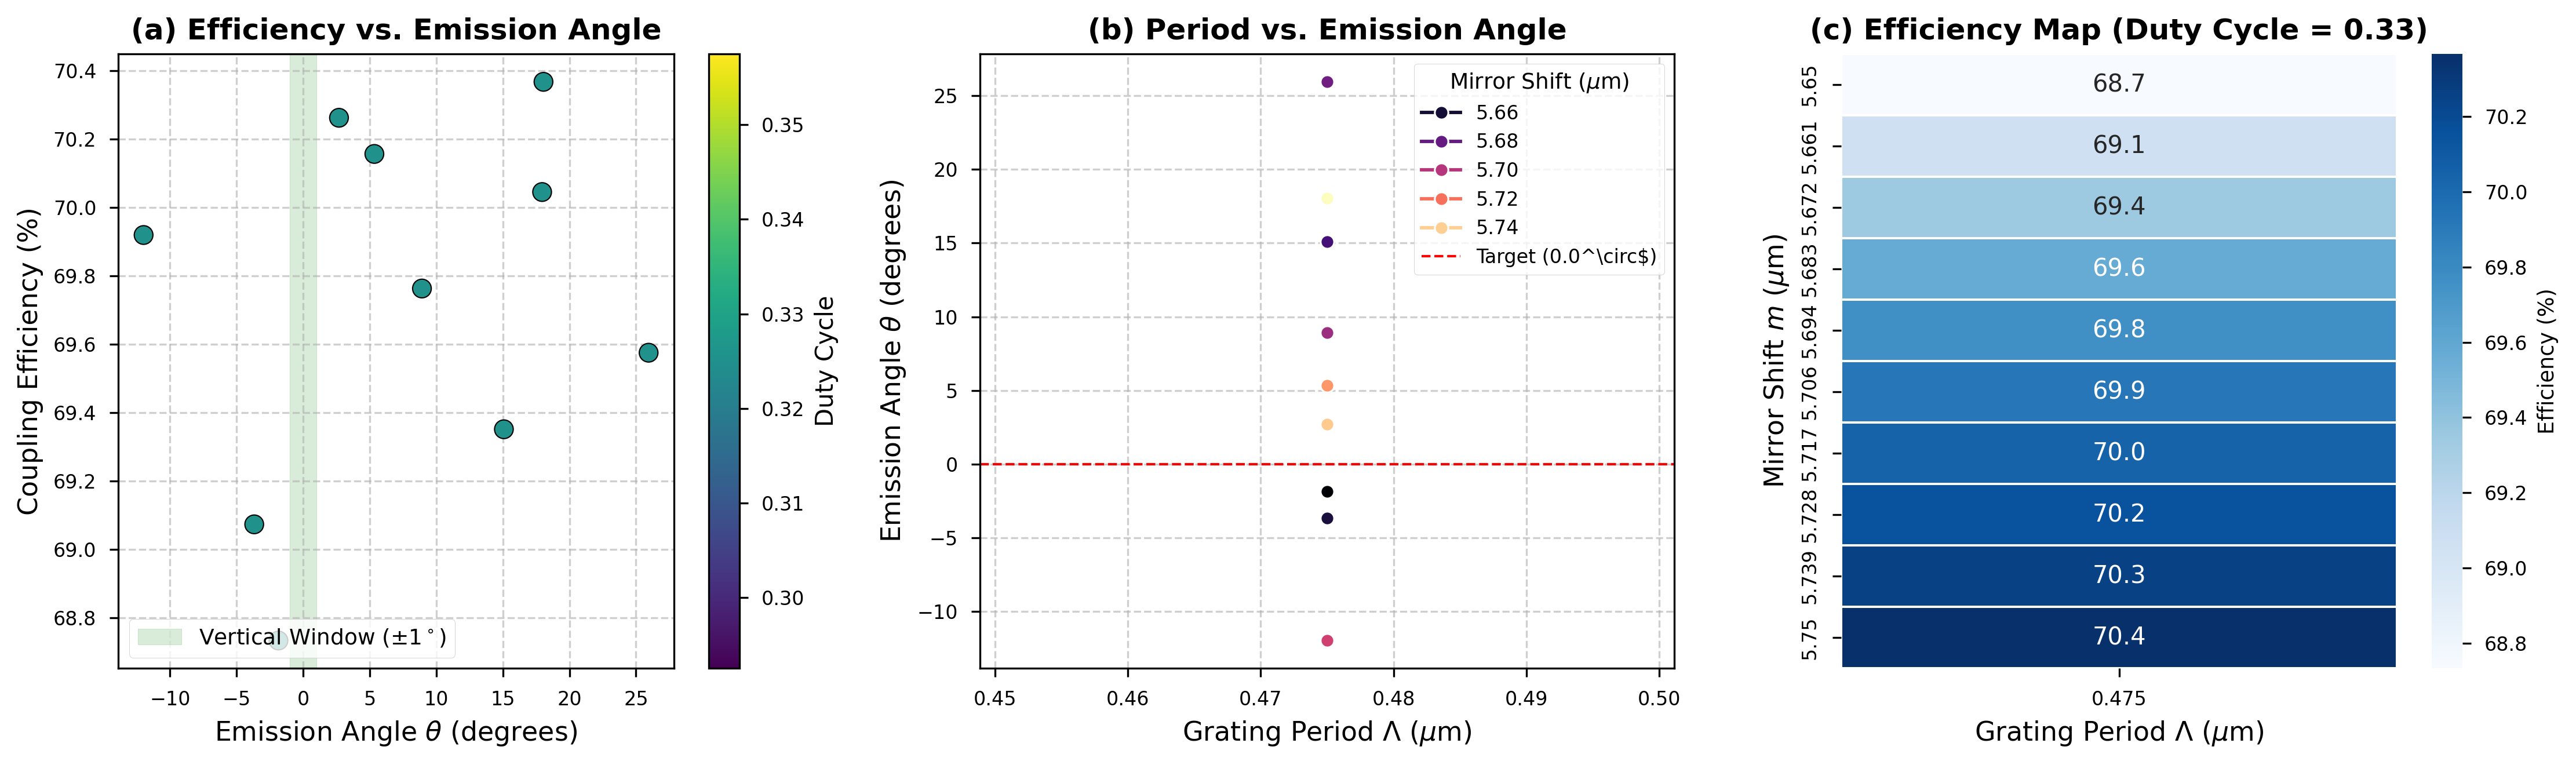

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set publication style
plt.style.use('seaborn-v0_8-paper' if 'seaborn-v0_8-paper' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=300)

# Colors
primary_color = '#1f77b4'
highlight_color = '#d62728'

reference_duty = 0.325
target_angle = 0.0

# -------------------------------------------------------------------------
# Plot (a): Coupling Efficiency vs. Emission Angle
# -------------------------------------------------------------------------
ax1 = axes[0]

# Draw vertical acceptance window (|angle| <= 1.0 deg)
ax1.axvspan(-1.0, 1.0, color='green', alpha=0.15, label='Vertical Window ($\pm 1^\circ$)')

# Scatter plot of all sweep points
scatter = ax1.scatter(
    df_results['emission_angle_deg'], 
    df_results['upward_flux_%'], 
    c=df_results['duty_cycle'], 
    cmap='viridis', 
    s=60, 
    edgecolor='k', 
    linewidth=0.5,
    zorder=3
)
cbar = fig.colorbar(scatter, ax=ax1)
cbar.set_label('Duty Cycle', fontsize=10)

# Highlight the optimal point (Design #3)
# opt_row = df_results[(df_results['period'] == 0.426) & (df_results['mirror_shift'] == 0.350) & (df_results['duty_cycle'] == 0.450)].iloc[0]
# ax1.scatter(
#     opt_row['emission_angle_deg'], 
#     opt_row['upward_flux_%'], 
#     color=highlight_color, 
#     s=150, 
#     marker='*', 
#     edgecolor='k', 
#     zorder=5, 
#     label=f'Optimal (-1.56 dB, {opt_row["emission_angle_deg"]:.2f}$^\circ$)'
# )

ax1.set_xlabel('Emission Angle $\\theta$ (degrees)', fontsize=11)
ax1.set_ylabel('Coupling Efficiency (%)', fontsize=11)
ax1.set_title('(a) Efficiency vs. Emission Angle', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='lower left', fontsize=9)

# -------------------------------------------------------------------------
# Plot (b): Beam Steering Curve (Period vs. Emission Angle)
# -------------------------------------------------------------------------
ax2 = axes[1]

# Filter for optimal duty cycle (0.450)
df_dc = df_results[df_results['duty_cycle'] == reference_duty]

sns.lineplot(
    data=df_dc, 
    x='period', 
    y='emission_angle_deg', 
    hue='mirror_shift', 
    palette='magma', 
    marker='o', 
    ax=ax2
)

ax2.axhline(target_angle, color='red', linestyle='--', linewidth=1, label=f'Target ({target_angle}^\circ$)')
ax2.set_xlabel('Grating Period $\Lambda$ ($\mu$m)', fontsize=11)
ax2.set_ylabel('Emission Angle $\\theta$ (degrees)', fontsize=11)
ax2.set_title('(b) Period vs. Emission Angle', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(title='Mirror Shift ($\mu$m)', fontsize=8, title_fontsize=9)

# -------------------------------------------------------------------------
# Plot (c): Efficiency Contour Map (Period vs. Mirror Shift for d=0.45)
# -------------------------------------------------------------------------
ax3 = axes[2]

pivot_eff = df_dc.pivot(index='mirror_shift', columns='period', values='upward_flux_%')

sns.heatmap(
    pivot_eff, 
    annot=True, 
    fmt=".1f", 
    cmap='Blues', 
    cbar_kws={'label': 'Efficiency (%)'}, 
    ax=ax3,
    linewidths=0.5
)

ax3.set_xlabel('Grating Period $\Lambda$ ($\mu$m)', fontsize=11)
ax3.set_ylabel('Mirror Shift $m$ ($\mu$m)', fontsize=11)
ax3.set_title(f'(c) Efficiency Map (Duty Cycle = {df_dc["duty_cycle"].iloc[0]:.2f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('psgc_optimization_results.png', dpi=300, bbox_inches='tight')
plt.show()